# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
Once upon a time, there was a peaceful village surrounded by green hills and a beautiful river.
The village was famous for its friendly people and colorful gardens.
Every morning, birds sang cheerful songs as the sun rose above the mountains.
Children laughed while walking to school with their friends.
Farmers worked hard in the fields from sunrise until sunset.
Everyone in the village believed that honesty and kindness were the greatest treasures.
Among the villagers lived a curious young boy named Alex.
Alex loved exploring forests, rivers, and hidden paths more than anything else.
He carried a small notebook where he wrote everything he discovered.
His grandfather often told him that knowledge was more valuable than gold.
Every evening, Alex listened carefully to his grandfather's stories.
The stories were filled with brave heroes, wise travelers, and mysterious forests.
One bright morning, Alex decided to explore a new path beyond the old bridge.
The path was narrow and covered with green moss.
Tall trees blocked most of the sunlight from reaching the ground.
The cool breeze carried the sweet fragrance of wild flowers.
As Alex walked deeper into the forest, he noticed colorful butterflies flying around him.
Small squirrels jumped from one tree to another without fear.
A gentle stream flowed quietly beside the walking trail.
The clear water reflected the blue sky like a mirror.
After walking for nearly an hour, Alex found an ancient stone covered with strange symbols.
The symbols looked like an old forgotten language.
He carefully copied every symbol into his notebook.
Suddenly, he heard the soft cry of a small bird nearby.
Alex followed the sound and discovered an injured bird trapped beneath a broken branch.
Alex carefully lifted the broken branch without hurting the bird.
He wrapped the bird gently in his scarf and carried it home.
His grandmother cleaned the bird's small wounds with warm water.
She prepared a comfortable nest using soft cotton and dry leaves.
Every morning Alex fed the bird fresh seeds and clean water.
The bird slowly became stronger with each passing day.
After two weeks the bird was healthy enough to fly again.
Alex opened the window and smiled as the bird flew into the blue sky.
Before leaving the bird circled above the house several times as if expressing gratitude.
The villagers admired Alex for his kindness toward every living creature.
Inspired by his actions many children began helping injured animals as well.
The forest gradually became a safer place for birds rabbits and deer.
One evening an old traveler arrived at the village carrying a dusty backpack.
He looked tired after walking for many days.
The traveler asked the villagers for food water and a place to rest.
Everyone welcomed him with kindness and respect.
During dinner the traveler shared stories about distant kingdoms and hidden treasures.
He showed Alex an old map that had faded with time.
According to the map an ancient library was hidden deep inside the forest.
The library was said to contain books filled with forgotten knowledge.
Alex became excited because he loved learning new things.
The traveler invited Alex to join him on the journey.
Alex thanked his family and promised to return safely.
Early the next morning they packed food water ropes and a lantern.
Together they began their adventure toward the mysterious forest.
The forest became darker as they walked farther from the village.
The traveler carefully followed the old map while Alex observed every landmark.
They crossed a wooden bridge over a fast flowing river.
After crossing the bridge they reached a rocky hill covered with tall trees.
The climb was difficult but neither of them gave up.
At the top of the hill they found a stone pillar with mysterious symbols.
Alex compared the symbols with those he had copied into his notebook.
To his surprise many of the symbols matched perfectly.
The traveler believed they were moving in the right direction.
Soon they reached a narrow cave hidden behind a beautiful waterfall.
The cool mist from the waterfall filled the air with freshness.
Inside the cave they discovered a heavy wooden door with an ancient lock.
A message carved into the stone read that wisdom would open the door.
Alex studied the symbols and realized they formed a simple puzzle.
After thinking carefully he arranged the stones in the correct order.
The wooden door slowly opened with a deep rumbling sound.
Beyond the door stood a magnificent underground library.
Thousands of old books filled tall wooden shelves from floor to ceiling.
The air smelled of old paper and polished wood.
A warm golden light entered through small openings in the ceiling.
Ancient maps scientific drawings and handwritten journals were carefully preserved.
The traveler smiled because the legendary library truly existed.
Alex gently opened the first book and discovered stories about explorers inventors and great teachers.
Every page encouraged readers to stay curious and continue learning.
Alex realized that knowledge was the greatest treasure anyone could ever find.
The traveler encouraged Alex to copy the most important ideas from the books.
Together they spent several days reading and taking careful notes.
They learned about science, mathematics, astronomy, farming, and medicine.
Every book contained practical lessons that could improve people's lives.
Before leaving, they carefully placed every book back on its shelf.
They promised to protect the library and keep its location a secret.
The journey back to the village felt much shorter than the journey into the forest.
When they returned home, the villagers gathered to hear their stories.
Alex explained that the greatest treasure was not gold but knowledge.
The villagers listened with great interest and respect.
They decided to build a public library in the center of the village.
Everyone contributed something to the project.
Carpenters built strong wooden shelves for the books.
Teachers volunteered to help children learn every evening.
Farmers shared practical knowledge about growing healthy crops.
Artists decorated the walls with colorful paintings of forests, rivers, and mountains.
Children visited the library every day after school.
They read books, asked questions, and imagined wonderful adventures.
The village slowly became famous for its education and kindness.
Visitors traveled from distant towns to learn from the village.
Alex continued exploring nature whenever he had free time.
He never stopped learning because he believed every day offered a new lesson.
Years later, Alex became known as the wise guardian of the forest and the village.
People remembered his courage, kindness, curiosity, and love of knowledge.
The story of Alex reminded everyone that true treasure is found in learning, sharing, and helping others.
"""
'''
print(corpus)


Once upon a time, there was a peaceful village surrounded by green hills and a beautiful river.
The village was famous for its friendly people and colorful gardens.
Every morning, birds sang cheerful songs as the sun rose above the mountains.
Children laughed while walking to school with their friends.
Farmers worked hard in the fields from sunrise until sunset.
Everyone in the village believed that honesty and kindness were the greatest treasures.
Among the villagers lived a curious young boy named Alex.
Alex loved exploring forests, rivers, and hidden paths more than anything else.
He carried a small notebook where he wrote everything he discovered.
His grandfather often told him that knowledge was more valuable than gold.
Every evening, Alex listened carefully to his grandfather's stories.
The stories were filled with brave heroes, wise travelers, and mysterious forests.
One bright morning, Alex decided to explore a new path beyond the old bridge.
The path was narrow and covered wi

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [15]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 486
X shape: (999, 16)
y shape: (999,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [16]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [17]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [18]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

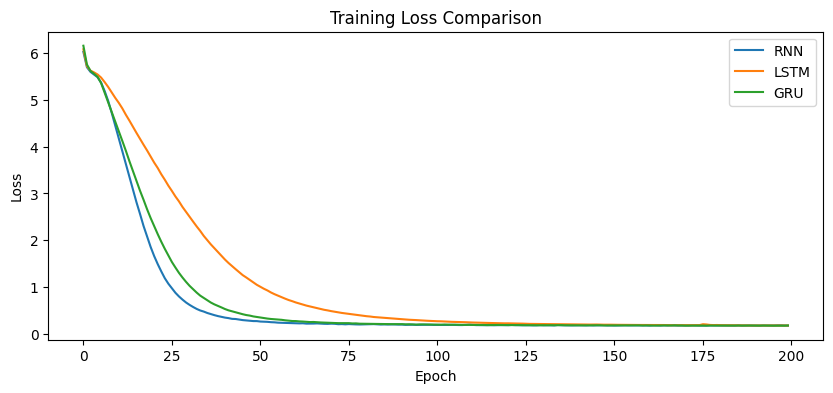

In [19]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [20]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [22]:
generate_text(rnn_model, "alex", 25)
generate_text(lstm_model, "alex", 25)
generate_text(gru_model, "alex", 25)

'alex studied the symbols and realized they formed a simple puzzle puzzle river river river river backpack river like library was notes notes backpack backpack backpack'

In [23]:
print("="*70)
print("Generated Text Quality Comparison")
print("="*70)

rnn_text = generate_text(rnn_model, "alex", 25)
lstm_text = generate_text(lstm_model, "alex", 25)
gru_text = generate_text(gru_model, "alex", 25)

print(f"RNN : {rnn_text}")
print(f"LSTM: {lstm_text}")
print(f"GRU : {gru_text}")

print("\nObservation:")
print("- RNN often repeats words and loses context.")
print("- LSTM usually generates more meaningful and grammatically correct text.")
print("- GRU performs close to LSTM while being computationally lighter.")

Generated Text Quality Comparison
RNN : alex became excited because he loved learning new things beyond the door stood a magnificent underground library every day offered a new lesson boy cleaned the
LSTM: alex explained that the greatest treasure was not gold but knowledge knowledge and helping others others others others others others others others others others others grandfather
GRU : alex studied the symbols and realized they formed a simple puzzle puzzle river river river river backpack river like library was notes notes backpack backpack backpack

Observation:
- RNN often repeats words and loses context.
- LSTM usually generates more meaningful and grammatically correct text.
- GRU performs close to LSTM while being computationally lighter.


## **** Memory Handling Comparison****

In [24]:
import pandas as pd

memory_df = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Memory Handling": [
        "Poor",
        "Excellent",
        "Very Good"
    ],
    "Reason": [
        "Vanishing gradient problem",
        "Uses Forget/Input/Output Gates",
        "Uses Update and Reset Gates"
    ]
})

memory_df

,Model,Memory Handling,Reason
0,Vanilla RNN,Poor,Vanishing gradient problem
1,LSTM,Excellent,Uses Forget/Input/Output Gates
2,GRU,Very Good,Uses Update and Reset Gates


## ****Long-Term Dependency Learning Comparison

In [25]:
dependency_df = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Long-Term Dependency": [
        "Weak",
        "Excellent",
        "Very Good"
    ],
    "Explanation": [
        "Cannot retain information over long sequences.",
        "Designed specifically for long-term dependencies.",
        "Retains long dependencies using fewer gates."
    ]
})

dependency_df

,Model,Long-Term Dependency,Explanation
0,Vanilla RNN,Weak,Cannot retain information over long sequences.
1,LSTM,Excellent,Designed specifically for long-term dependencies.
2,GRU,Very Good,Retains long dependencies using fewer gates.


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**